# Fallstudie: Analyse visueller Suchverfahren (Wo ist Waldo)
**Modul:** Grundlagen des wissenschaftlichen Arbeitens  
**Thema:** Untersuchung der Lese-Hypothese (Top-Down, Left-to-Right) mittels Eye-Tracking-Daten & Machine Learning Classifier

---

### Inhaltsverzeichnis
1. **Setup & Datenimport**: Laden und Bereinigen der Rohdaten (`Data export`) und aggregierten Daten (`Metrics`).
2. **Explorative Datenanalyse & Visualisierung**: Statistische Aufbereitung der Probanden-Metriken mit Seaborn.
3. **Hypothesen-Test (Die Lese-Strategie)**: Zeitliche Analyse der $X$- und $Y$-Koordinaten zur Validierung systematischer Muster (Sägezahn & Top-Down).
4. **Feature Engineering & Machine Learning**: Klassifikation von Sucherfolgen/Verhalten basierend auf extrahierten Merkmalen.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from PIL import Image
import os

# Matplotlib & Seaborn Styling für wissenschaftliche Arbeiten
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Bibliotheken erfolgreich geladen!")

Bibliotheken erfolgreich geladen!


## 1. Data Loading & Preprocessing
Wir laden den vollständigen **Data Export** (für die Koordinaten-Zeitreihen) und den **Metrics Export** (für die aggregierten Probanden-Kennzahlen).

In [3]:
# 1. Daten laden (Tab-getrennt)
df_data = pd.read_csv('data/EHBR Data export.tsv', sep='\t', low_memory=False)
df_metrics = pd.read_csv('data/EHBR Metrics.tsv', sep='\t')

# Spaltennamen bereinigen
df_data.columns = df_data.columns.str.strip()
df_metrics.columns = df_metrics.columns.str.strip()

# Testaufzeichnungen entfernen
df_data = df_data[~df_data['Participant name'].isin(['Test', 'Test2'])]
df_metrics = df_metrics[~df_metrics['Participant'].isin(['Test', 'Test2'])]

print(f"Data Export geladen: {df_data.shape[0]} Zeilen, {df_data.shape[1]} Spalten.")
print(f"Metrics Export geladen: {df_metrics.shape[0]} Zeilen, {df_metrics.shape[1]} Spalten.")

Data Export geladen: 112287 Zeilen, 98 Spalten.
Metrics Export geladen: 56 Zeilen, 11 Spalten.


## 2. Explorative Datenanalyse (Metrics)
Hier analysieren wir die Verteilungen der Fixationen und Sakkaden über die verschiedenen Suchbilder (`TOI`).

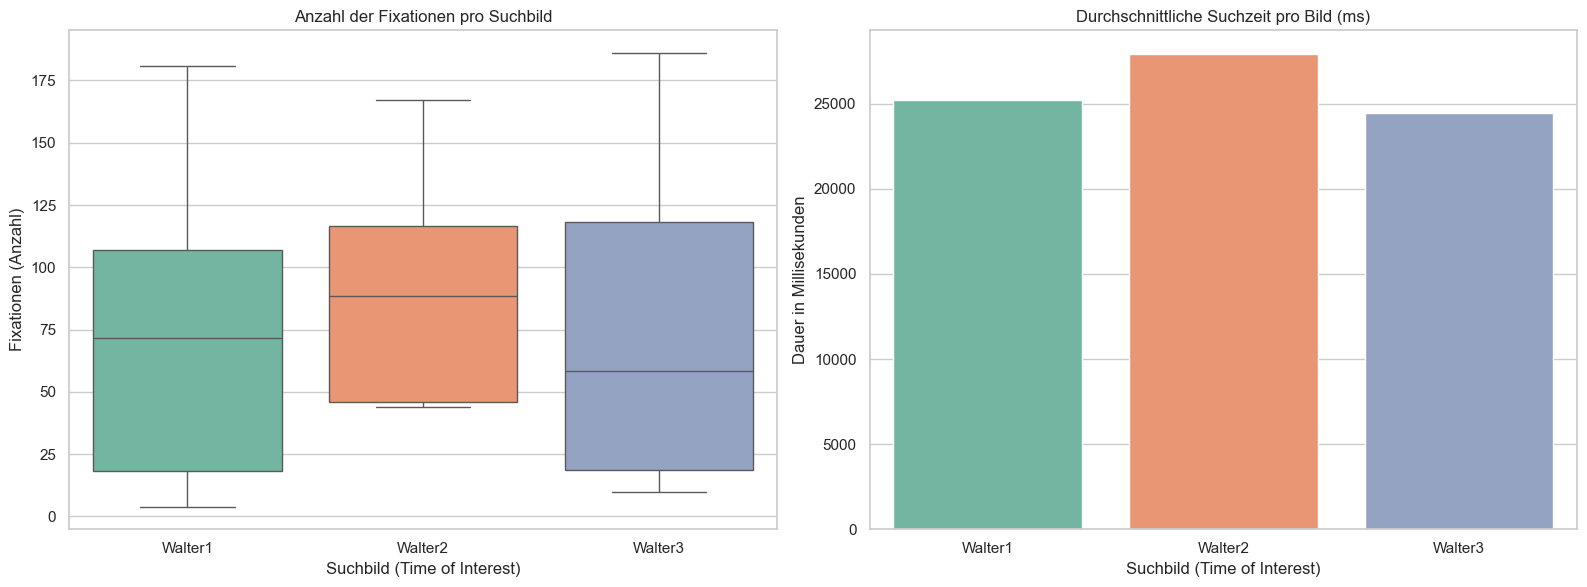

In [4]:
# Filtern auf die primären Suchbilder (ohne 'Entire Recording')
walter_metrics = df_metrics[df_metrics['TOI'].isin(['Walter1', 'Walter2', 'Walter3'])].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot: Anzahl der Fixationen pro Bild
sns.boxplot(data=walter_metrics, x='TOI', y='Number_of_whole_fixations', hue='TOI', legend=False, ax=ax1, palette='Set2')
ax1.set_title('Anzahl der Fixationen pro Suchbild')
ax1.set_xlabel('Suchbild (Time of Interest)')
ax1.set_ylabel('Fixationen (Anzahl)')

# Barplot: Durchschnittliche Intervalldauer (Suchzeit)
sns.barplot(data=walter_metrics, x='TOI', y='Duration_of_interval', hue='TOI', legend=False, ax=ax2, palette='Set2', errorbar=None)
ax2.set_title('Durchschnittliche Suchzeit pro Bild (ms)')
ax2.set_xlabel('Suchbild (Time of Interest)')
ax2.set_ylabel('Dauer in Millisekunden')

plt.tight_layout()
plt.show()

## 3. Test der Forschungs-Hypothese: Suchen Menschen wie sie lesen?
**Hypothese:** Der Blick wandert im Zeitverlauf kontinuierlich von oben nach unten ($Y$-Koordinate steigt) und zeigt horizontal ein zyklisches Sägezahnmuster ($X$-Koordinate steigt zeilenweise von links nach rechts und springt abrupt zurück).

In [5]:
# Wir wählen die erste valide Testaufzeichnung aus dem Data Export
available_participants = df_data['Participant name'].dropna().unique()
print("Verfügbare Probanden im Datensatz:", available_participants)

# Auswahl des ersten echten Probanden und eines Waldo-Bildes
chosen_participant = available_participants[0]
chosen_media = 'Walter1.jpg'

# Filterung und Bereinigung von fehlenden Blickpunkten
df_hyp = df_data[(df_data['Participant name'] == chosen_participant) & 
                 (df_data['Presented Media name'] == chosen_media)].copy()

df_hyp = df_hyp.dropna(subset=['Gaze point X', 'Gaze point Y'])

# Zeitachse in Sekunden ab Start des Stimulus berechnen
df_hyp['Time_Sec'] = (df_hyp['Computer timestamp'] - df_hyp['Computer timestamp'].min()) / 1_000_000

print(f"Analyse für {chosen_participant} auf {chosen_media} mit {len(df_hyp)} validen Blickpunkten.")

Verfügbare Probanden im Datensatz: <StringArray>
['ID01', 'ID02', 'ID03', 'ID04', 'ID05', 'ID06', 'ID07', 'ID08']
Length: 8, dtype: str
Analyse für ID01 auf Walter1.jpg mit 3558 validen Blickpunkten.


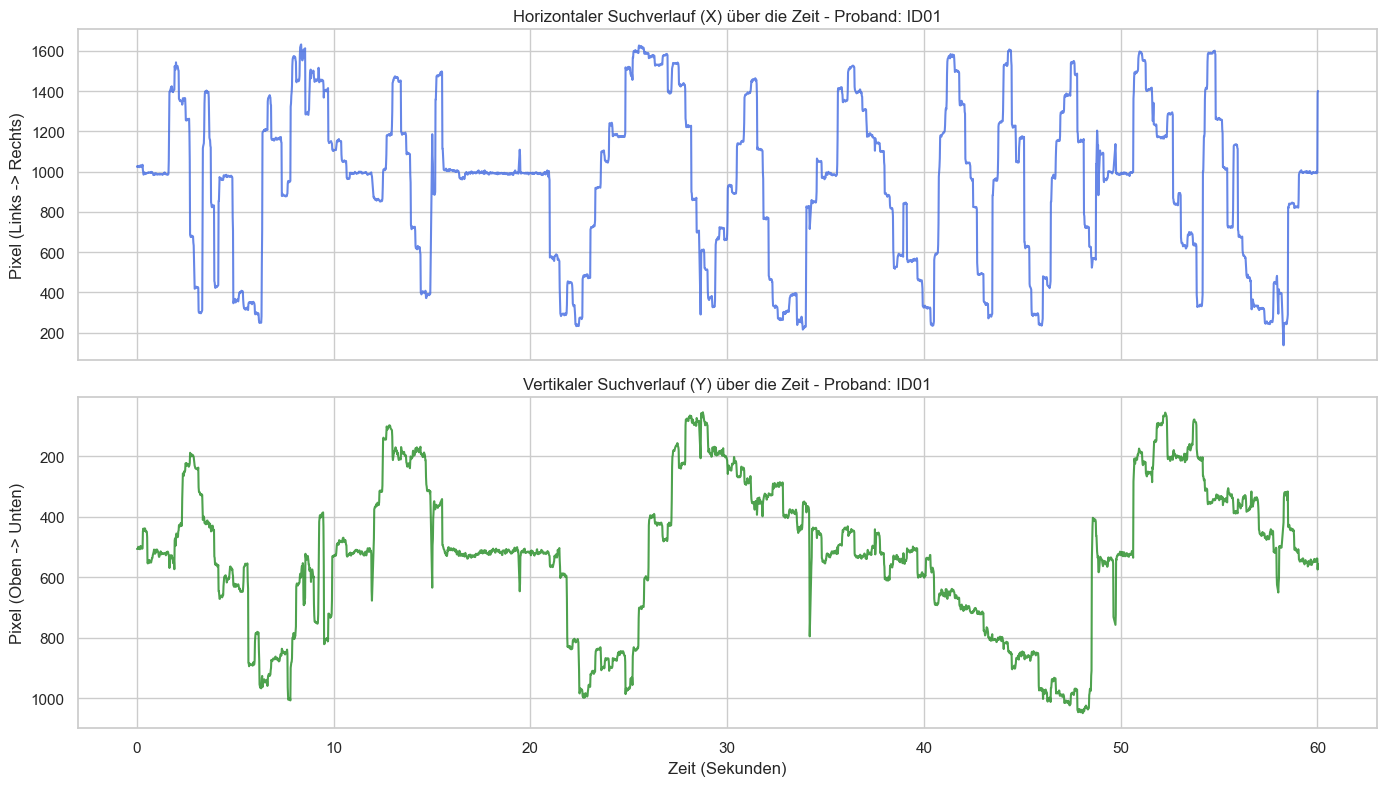

--- Statistische Ergebnisse für ID01 ---
Spearman-Korrelation (Zeit vs. X): -0.096 (p-Wert: 0.0000)
Spearman-Korrelation (Zeit vs. Y): -0.068 (p-Wert: 0.0000) -> Ein positiver Wert stützt die Lese-Hypothese (Top-Down)!


In [6]:
# Visualisierung der X- und Y-Blickpfade über die Zeitachse
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# 1. Horizontaler Blickverlauf (X-Achse)
sns.lineplot(data=df_hyp, x='Time_Sec', y='Gaze point X', ax=ax1, color='royalblue', alpha=0.8)
ax1.set_title(f'Horizontaler Suchverlauf (X) über die Zeit - Proband: {chosen_participant}')
ax1.set_ylabel('Pixel (Links -> Rechts)')
ax1.grid(True)

# 2. Vertikaler Blickverlauf (Y-Achse)
sns.lineplot(data=df_hyp, x='Time_Sec', y='Gaze point Y', ax=ax2, color='forestgreen', alpha=0.8)
ax2.set_title(f'Vertikaler Suchverlauf (Y) über die Zeit - Proband: {chosen_participant}')
ax2.set_xlabel('Zeit (Sekunden)')
ax2.set_ylabel('Pixel (Oben -> Unten)')
ax2.invert_yaxis()  # Wichtig: Pixel 0 ist oben am Bildschirm!
ax2.grid(True)

plt.tight_layout()
plt.show()

# Statistischer Nachweis mittels Spearman-Rangkorrelation
rho_x, p_x = spearmanr(df_hyp['Time_Sec'], df_hyp['Gaze point X'])
rho_y, p_y = spearmanr(df_hyp['Time_Sec'], df_hyp['Gaze point Y'])

print(f"--- Statistische Ergebnisse für {chosen_participant} ---")
print(f"Spearman-Korrelation (Zeit vs. X): {rho_x:.3f} (p-Wert: {p_x:.4f})")
print(f"Spearman-Korrelation (Zeit vs. Y): {rho_y:.3f} (p-Wert: {p_y:.4f}) -> Ein positiver Wert stützt die Lese-Hypothese (Top-Down)!")

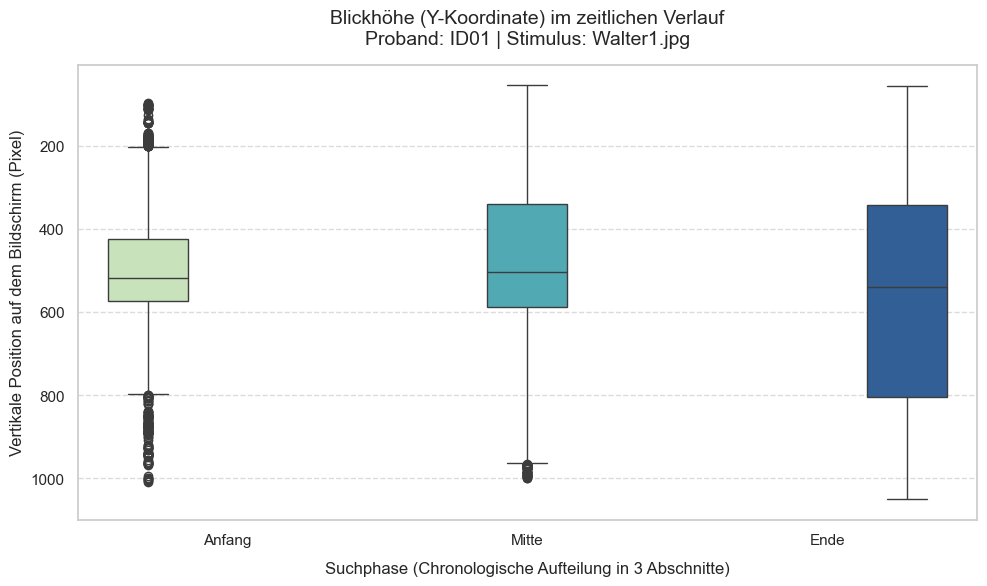

--- Deskriptive Statistik der Blickhöhe (Y) pro Phase ---
Phase
Anfang    515.080944
Mitte     495.085160
Ende      562.384486


In [7]:
# 1. Datenbasis vorbereiten (Wir nutzen das bereits gefilterte 'df_hyp' aus Schritt 3)
if 'df_hyp' in locals() and not df_hyp.empty:

    # Sicherstellen, dass keine Kopier-Warnung auftritt
    df_phase = df_hyp.copy()

    # 2. Suchzeit in 3 gleich große Abschnitte (Terzile) unterteilen
    # qcut sorgt dafür, dass in jeder Phase gleich viele Datenpunkte liegen
    df_phase['Phase'] = pd.qcut(df_phase['Time_Sec'], q=3, labels=['Anfang', 'Mitte', 'Ende'])

    # 3. Plot erstellen
    plt.figure(figsize=(10, 6))

    # Boxplot für die Y-Koordinate pro Phase
    sns.boxplot(
        data=df_phase,
        x='Phase',
        y='Gaze point Y',
        palette='YlGnBu',
        hue='Phase',
        legend=False
    )

    # 4. Achsenspiegelung (Kritisch bei Eye-Tracking-Daten!)
    plt.gca().invert_yaxis()

    # Beschriftungen
    plt.title(f'Blickhöhe (Y-Koordinate) im zeitlichen Verlauf\nProband: {chosen_participant} | Stimulus: {chosen_media}', fontsize=14, pad=15)
    plt.xlabel('Suchphase (Chronologische Aufteilung in 3 Abschnitte)', fontsize=12, labelpad=10)
    plt.ylabel('Vertikale Position auf dem Bildschirm (Pixel)', fontsize=12)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # 5. Deskriptive Zusatzstatistik für den Fließtext der Arbeit ausgeben
    print("--- Deskriptive Statistik der Blickhöhe (Y) pro Phase ---")
    print(df_phase.groupby('Phase', observed=False)['Gaze point Y'].mean().to_string())

else:
    print("Fehler: Bitte führe zuerst die Zelle aus Schritt 3 aus, um 'df_hyp' zu definieren.")

## 3b. Spearman-Korrelation für alle Probanden & Bilder
Wir berechnen die Korrelation zwischen Zeit und Y-Koordinate (Top-Down) sowie Zeit und X-Koordinate (Links-Rechts) für alle Kombination aus Proband und Stimulus.

In [9]:
# Spearman-Korrelation für alle Probanden × alle Stimuli berechnen
stimuli_files = {'Walter1': 'Walter1.jpg', 'Walter2': 'Walter2.jpg', 'Walter3': 'Walter3.jpg'}
corr_records = []

for pid in sorted(df_data['Participant name'].dropna().unique()):
    for stim_label, stim_file in stimuli_files.items():
        subset = df_data[
            (df_data['Participant name'] == pid) &
            (df_data['Presented Media name'] == stim_file)
        ].dropna(subset=['Gaze point X', 'Gaze point Y']).copy()

        if len(subset) < 10:
            continue

        t = (subset['Computer timestamp'] - subset['Computer timestamp'].min()) / 1_000_000
        rho_y, p_y = spearmanr(t, subset['Gaze point Y'])
        rho_x, p_x = spearmanr(t, subset['Gaze point X'])

        corr_records.append({
            'Proband': pid, 'Stimulus': stim_label,
            'rho_Y (Top-Down)': round(rho_y, 3), 'p_Y': round(p_y, 4),
            'rho_X (Links-Rechts)': round(rho_x, 3), 'p_X': round(p_x, 4),
            'sig_Y': '***' if p_y < 0.001 else ('**' if p_y < 0.01 else ('*' if p_y < 0.05 else '–')),
            'sig_X': '***' if p_x < 0.001 else ('**' if p_x < 0.01 else ('*' if p_x < 0.05 else '–')),
        })

df_corr = pd.DataFrame(corr_records)
print(df_corr[['Proband','Stimulus','rho_Y (Top-Down)','sig_Y','rho_X (Links-Rechts)','sig_X']].to_string(index=False))
print()
print("Mittelwerte:")
print(f"  rho_Y (Top-Down):     {df_corr['rho_Y (Top-Down)'].mean():.3f}")
print(f"  rho_X (Links-Rechts): {df_corr['rho_X (Links-Rechts)'].mean():.3f}")

Proband Stimulus  rho_Y (Top-Down) sig_Y  rho_X (Links-Rechts) sig_X
   ID01  Walter1            -0.068   ***                -0.096   ***
   ID01  Walter2            -0.159   ***                -0.036     –
   ID01  Walter3             0.335   ***                 0.289   ***
   ID02  Walter1             0.029     –                -0.004     –
   ID02  Walter2            -0.675   ***                -0.354   ***
   ID02  Walter3            -0.086     *                 0.186   ***
   ID03  Walter1            -0.370   ***                 0.382   ***
   ID03  Walter2             0.150   ***                 0.206   ***
   ID03  Walter3            -0.291   ***                 0.617   ***
   ID04  Walter1            -0.191   ***                 0.162   ***
   ID04  Walter2            -0.242   ***                 0.253   ***
   ID04  Walter3             0.373   ***                 0.835   ***
   ID05  Walter1             0.133     –                 0.626   ***
   ID05  Walter2            -0.130

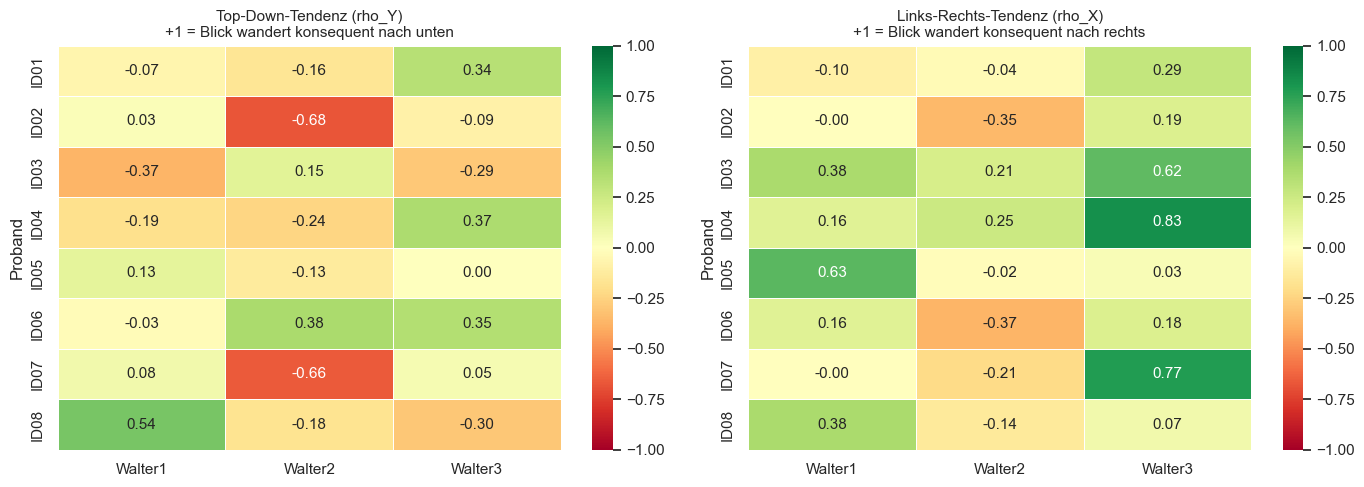

In [10]:
# Visualisierung als Heatmap: rho_Y und rho_X für alle Probanden × Stimuli
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes,
    ['rho_Y (Top-Down)', 'rho_X (Links-Rechts)'],
    ['Top-Down-Tendenz (rho_Y)\n+1 = Blick wandert konsequent nach unten',
     'Links-Rechts-Tendenz (rho_X)\n+1 = Blick wandert konsequent nach rechts']):

    pivot = df_corr.pivot(index='Proband', columns='Stimulus', values=col)
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
                vmin=-1, vmax=1, ax=ax, linewidths=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

## 4. Heatmap-Analyse der Blickdaten
Für jeden Probanden liegen vorberechnete Heatmap-Bilder vor. Wir analysieren diese maschinell, um zwei Fragen zu beantworten:
1. **Konzentration**: Wie fokussiert wurde gesucht? (Anteil der aktiv betrachteten Bildfläche)
2. **Vertikale Verteilung**: Liegt die Aktivität eher oben oder unten? (Stützt die Top-Down-Hypothese)

In [11]:
import glob as _glob

def find_heatmap(pid, stim):
    """Findet die Heatmap-Datei unabhängig von Leerzeichen-Variationen im Dateinamen."""
    matches = _glob.glob(f'data/{pid}/{stim}*Heat*.png')
    return matches[0] if matches else None

def analyse_heatmap(path):
    img = np.array(Image.open(path))
    r, g, b = img[:,:,0].astype(int), img[:,:,1].astype(int), img[:,:,2].astype(int)
    warm = (r - g > 40) & (r - b > 40)
    coverage = warm.mean()
    h = warm.shape[0]
    top_act    = warm[:h//3].mean()
    mid_act    = warm[h//3:2*h//3].mean()
    bottom_act = warm[2*h//3:].mean()
    row_weights = warm.sum(axis=1)
    center_y = np.average(np.arange(h), weights=row_weights) / h if row_weights.sum() > 0 else np.nan
    return coverage, center_y, top_act, mid_act, bottom_act

participants = sorted([d for d in os.listdir('data') if d.startswith('ID')])
stimuli = ['Walter1', 'Walter2', 'Walter3']

records = []
for pid in participants:
    for stim in stimuli:
        path = find_heatmap(pid, stim)
        if not path:
            print(f"WARNUNG: Keine Heatmap für {pid} / {stim}")
            continue
        cov, cy, top, mid, bot = analyse_heatmap(path)
        records.append({
            'Proband': pid, 'Stimulus': stim,
            'Flächendeckung_%': round(cov * 100, 2),
            'Vertikaler_Schwerpunkt': round(cy, 3),
            'Aktivität_Oben': round(top * 100, 2),
            'Aktivität_Mitte': round(mid * 100, 2),
            'Aktivität_Unten': round(bot * 100, 2),
        })

df_heat = pd.DataFrame(records)
print(f"{len(df_heat)} Heatmaps analysiert.\n")
print(df_heat.to_string(index=False))

24 Heatmaps analysiert.

Proband Stimulus  Flächendeckung_%  Vertikaler_Schwerpunkt  Aktivität_Oben  Aktivität_Mitte  Aktivität_Unten
   ID01  Walter1              6.44                   0.653            1.40             7.96             9.94
   ID01  Walter2              6.50                   0.714            1.98             5.71            11.80
   ID01  Walter3              2.64                   0.600            1.37             3.05             3.49
   ID02  Walter1              9.81                   0.602            3.49            13.29            12.65
   ID02  Walter2              6.06                   0.675            2.44             5.82             9.91
   ID02  Walter3              3.05                   0.648            1.08             3.28             4.78
   ID03  Walter1             10.15                   0.599            3.95            13.46            13.05
   ID03  Walter2              4.80                   0.705            1.43             4.45            

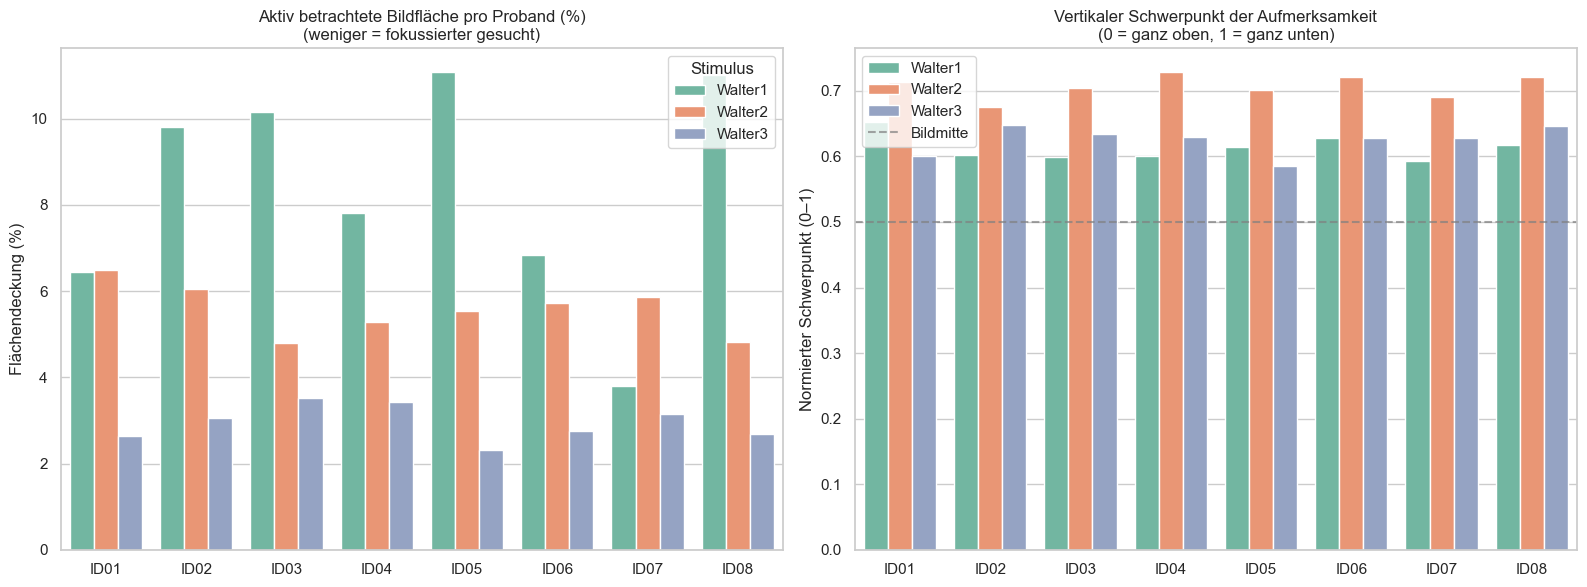

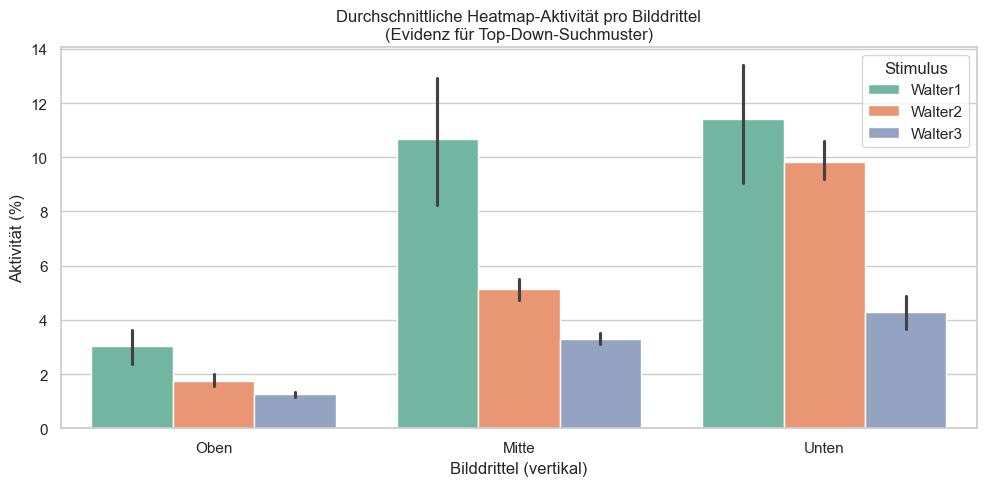

In [12]:
# 4a. Übersichtsplot: Flächendeckung & vertikaler Schwerpunkt pro Proband und Stimulus
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=df_heat, x='Proband', y='Flächendeckung_%', hue='Stimulus',
            palette='Set2', ax=axes[0])
axes[0].set_title('Aktiv betrachtete Bildfläche pro Proband (%)\n(weniger = fokussierter gesucht)')
axes[0].set_ylabel('Flächendeckung (%)')
axes[0].set_xlabel('')

sns.barplot(data=df_heat, x='Proband', y='Vertikaler_Schwerpunkt', hue='Stimulus',
            palette='Set2', ax=axes[1])
axes[1].set_title('Vertikaler Schwerpunkt der Aufmerksamkeit\n(0 = ganz oben, 1 = ganz unten)')
axes[1].set_ylabel('Normierter Schwerpunkt (0–1)')
axes[1].set_xlabel('')
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='Bildmitte')
axes[1].legend()

plt.tight_layout()
plt.show()

# 4b. Drittels-Verteilung: Wie viel Aktivität liegt oben vs. unten?
df_thirds = df_heat.melt(
    id_vars=['Proband', 'Stimulus'],
    value_vars=['Aktivität_Oben', 'Aktivität_Mitte', 'Aktivität_Unten'],
    var_name='Bilddrittel', value_name='Aktivität_%'
)
df_thirds['Bilddrittel'] = df_thirds['Bilddrittel'].str.replace('Aktivität_', '')

plt.figure(figsize=(10, 5))
sns.barplot(data=df_thirds, x='Bilddrittel', y='Aktivität_%', hue='Stimulus',
            palette='Set2', order=['Oben', 'Mitte', 'Unten'])
plt.title('Durchschnittliche Heatmap-Aktivität pro Bilddrittel\n(Evidenz für Top-Down-Suchmuster)')
plt.ylabel('Aktivität (%)')
plt.xlabel('Bilddrittel (vertikal)')
plt.tight_layout()
plt.show()

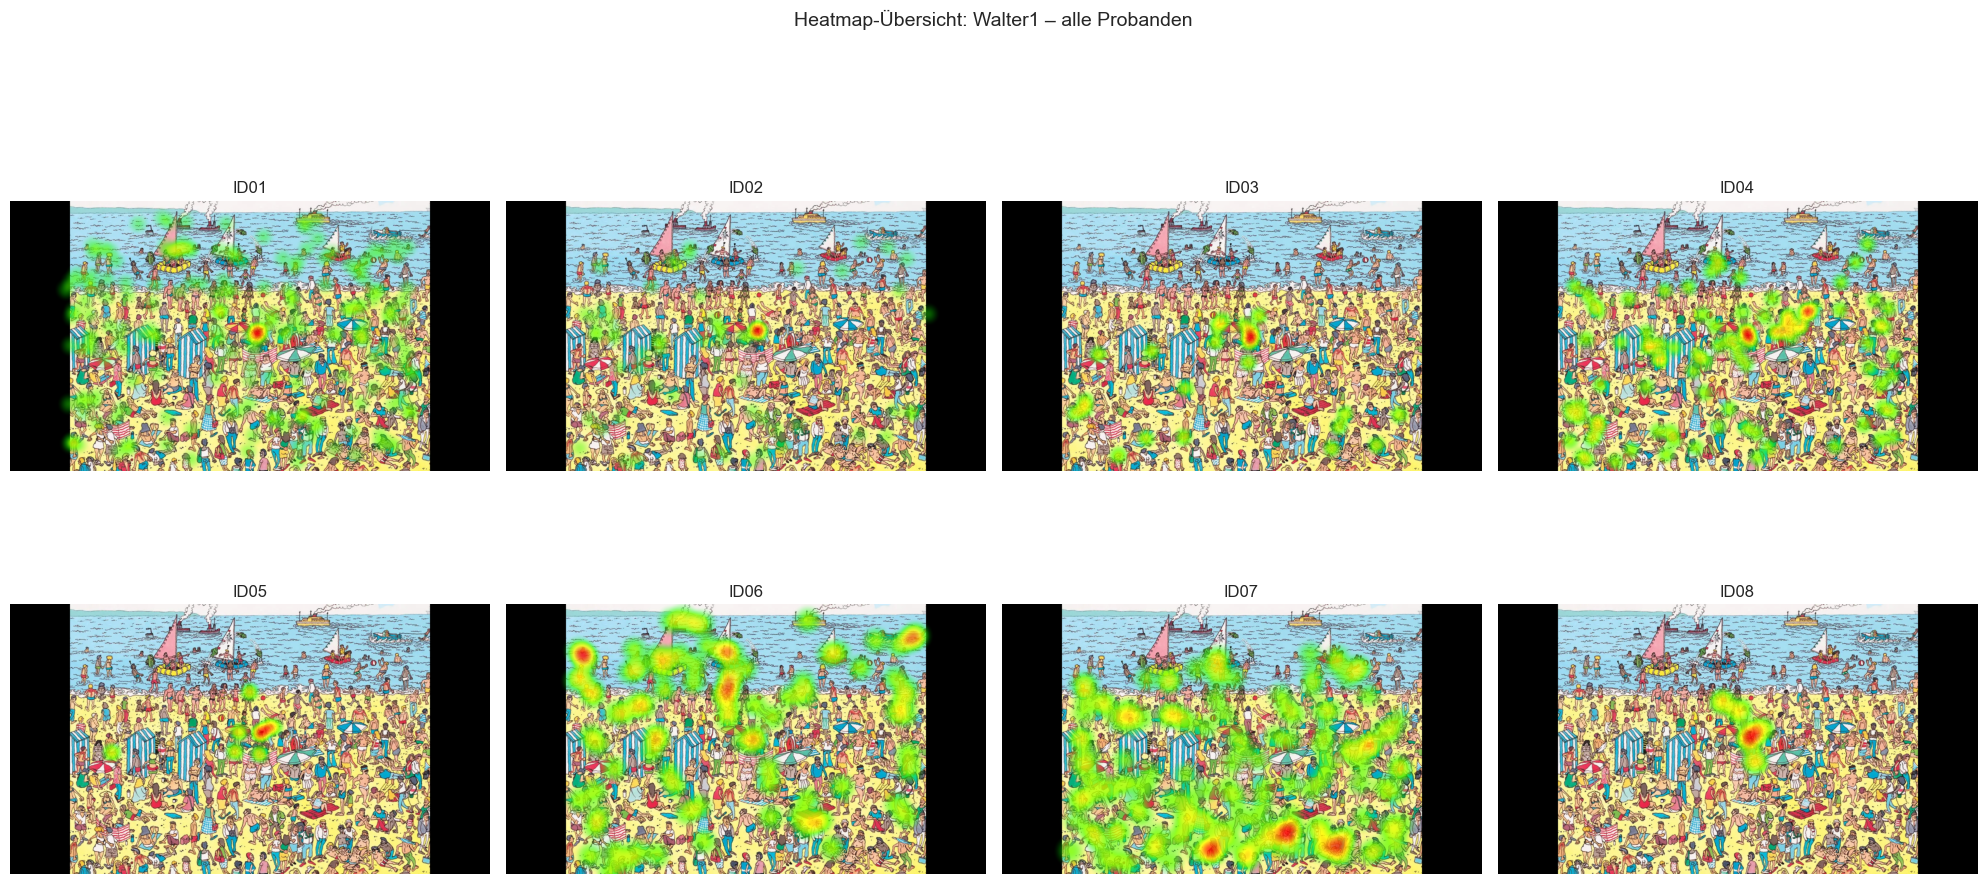

In [13]:
# 4c. Heatmap-Übersicht: Alle Probanden für Walter1 nebeneinander
stim_to_show = 'Walter1'
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, pid in enumerate(participants):
    path = find_heatmap(pid, stim_to_show)
    if path:
        axes[i].imshow(Image.open(path))
        axes[i].set_title(pid, fontsize=12)
    axes[i].axis('off')

for j in range(len(participants), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f'Heatmap-Übersicht: {stim_to_show} – alle Probanden', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()